In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import unicodedata

In [22]:
gcms_df = pd.read_csv('filtered_gc-ms_data.csv', engine='python')
seed_area_df = pd.read_csv('seed_area_approximations.csv', engine='python')

In [ ]:
# final decisions on which compounds are seed-derived
vacuum_whole = pd.read_excel("gcms_compound_diagnostics_final.xlsx", sheet_name="vacuum whole")[['compound_name', 'final_verdict']]
vacuum_cut = pd.read_excel("gcms_compound_diagnostics_final.xlsx", sheet_name="vacuum cut")[['compound_name', 'final_verdict']]
norm_atm_whole = pd.read_excel("gcms_compound_diagnostics_final.xlsx", sheet_name="normal atmosphere whole")[['compound_name', 'final_verdict']]

In [ ]:
# normalise compound names to create a global ID map
HYPHENS_RE = re.compile(r"[\u2010\u2011\u2012\u2013\u2014\u2212]")  # ‐-‒–—−
SQUARE_BRACKETS_RE = re.compile(r"\[[^\]]*\]")

# Remove things like (E), (Z), (E,Z), (R), (S), (all-Z), cis/trans etc
STEREO_PARENS_RE = re.compile(
    r"\(\s*(?:[ersz]|[ez]\s*,\s*[ez]|cis|trans|dl|d|l|all-z|all\s*-\s*z|e,e,e|e,z|z,e|e,e|z,z)\s*\)",
    flags=re.IGNORECASE,
)

DOT_GREEK_REPLACEMENTS = {
    r"\.alpha\.": " alpha ",
    r"\.beta\.":  " beta ",
    r"\.gamma\.": " gamma ",
    r"\.delta\.": " delta ",
}

GREEK_CHAR_MAP = {"α":"alpha","β":"beta","γ":"gamma","δ":"delta","ε":"epsilon","μ":"mu","ω":"omega"}
LEADING_STEREO_PREFIX_RE = re.compile(r"^(?:cis|trans|dl|d|l)\s*-\s*", flags=re.IGNORECASE)

def normalise_compound_name(s) -> str:
    if s is None:
        return ""
    if not isinstance(s, str):
        s = str(s)

    s = unicodedata.normalize("NFKC", s).lower()
    s = HYPHENS_RE.sub("-", s)

    # greek chars
    for g, w in GREEK_CHAR_MAP.items():
        s = s.replace(g, w)

    # ".beta." style
    for pat, repl in DOT_GREEK_REPLACEMENTS.items():
        s = re.sub(pat, repl, s, flags=re.IGNORECASE)

    # remove bracket blocks like [1R-(...)]
    s = SQUARE_BRACKETS_RE.sub(" ", s)

    # Remove parenthetical stereochem blocks that contain alpha/beta (or greek letters)
    s = re.sub(r"\([^)]*(?:alpha|beta|gamma|delta|α|β|γ|δ)[^)]*\)\s*-?", " ", s, flags=re.IGNORECASE)

    # remove small stereo parentheses
    s = STEREO_PARENS_RE.sub(" ", s)

    # drop leading "trans-" / "cis-" etc (outside parentheses)
    s = LEADING_STEREO_PREFIX_RE.sub("", s)

    # remove stray leading dots
    s = re.sub(r"^\.+", "", s)

    # keep letters/digits/hyphens/spaces, turn other punctuation into spaces
    s = re.sub(r"[^a-z0-9\-\s]", " ", s)

    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()

    # KEY STEP: collapse spaces around hyphens so "beta -myrcene" -> "beta-myrcene"
    s = re.sub(r"\s*-\s*", "-", s)

    # strip trailing hyphens
    s = re.sub(r"-+$", "", s)

    return s

In [27]:
# --- normalise all inputs the same way ---
gcms_df["compound_norm"] = gcms_df["compound_name"].map(normalise_compound_name)

vacuum_whole["compound_norm"] = vacuum_whole["compound_name"].map(normalise_compound_name)
vacuum_cut["compound_norm"]   = vacuum_cut["compound_name"].map(normalise_compound_name)
norm_atm_whole["compound_norm"]= norm_atm_whole["compound_name"].map(normalise_compound_name)

# --- rename seed-derived columns so you don't overwrite/drop them accidentally ---
vw = vacuum_whole.rename(columns={"final_verdict": "seed_derived_vacuum_whole"})[["compound_norm", "seed_derived_vacuum_whole"]]
vc = vacuum_cut.rename(columns={"final_verdict": "seed_derived_vacuum_cut"})[["compound_norm", "seed_derived_vacuum_cut"]]
na = norm_atm_whole.rename(columns={"final_verdict": "seed_derived_norm_atm_whole"})[["compound_norm", "seed_derived_norm_atm_whole"]]

merged_df = (
    gcms_df
    .merge(vw, on="compound_norm", how="left")
    .merge(vc, on="compound_norm", how="left")
    .merge(na, on="compound_norm", how="left")
)

# combine flags (first non-null across the three)
merged_df["seed_derived"] = (
    merged_df["seed_derived_vacuum_whole"]
    .combine_first(merged_df["seed_derived_vacuum_cut"])
    .combine_first(merged_df["seed_derived_norm_atm_whole"])
)

merged_df = merged_df.drop(columns=["seed_derived_vacuum_whole", "seed_derived_vacuum_cut", "seed_derived_norm_atm_whole"])

In [ ]:
oil_markers = ['Nonadecane',
'Octadecane',
'Heneicosane',
'Eicosane',
'Henicos-1-ene',
'Octadecane, 3-methyl-',
'Heptadecane, 3-methyl-',
'Octadecane, 2-methyl-',
'Nonanoic acid',
'β-Myrcene',
'p-Cymene',
'2,6-Octadien-1-ol, 3,7-dimethyl-, acetate (Z)',
'Pentadecane',
'1-Tetradecanol',
'Geraniol',
'6-Hydroxy-3,7-dimethyl-2,7-octadienyl acetate (E)',
'2,6-Octadien-1-ol, 3,7-dimethyl-, acetate (Z)',
'Acetic acid, 3-methyl-6-oxo-hex-2-enyl ester'
]

oil_markers = [normalise_compound_name(c) for c in oil_markers]

ageing_markers = ['Hexadecanal',
'Pentadecanal',
'Butanoic acid, 2-methyl-',
'Acetone',
'2-Octenal (E)',
'2-Decenal (E)',
'Furan, 2-pentyl-',
'1-Hexanol',
'Benzaldehyde',
]

ageing_markers = [normalise_compound_name(c) for c in ageing_markers]

In [91]:
def compound_presence_tables(
    df,
    species_col="species",
    treatment_col="treatment",
    compound_col="compound_name",
    seed_derived_col="seed_derived",
    oil_markers=oil_markers,
    ageing_markers=ageing_markers,
    treatments=None,
    drop_empty_species=True,
    empty_label="Empty",
):
    
    # normalise marker lists
    oil_markers = {c.lower().strip() for c in oil_markers}
    ageing_markers = {c.lower().strip() for c in ageing_markers}

    results = {}

    if drop_empty_species:
        df = df[df[species_col] != empty_label].copy()
    else:
        df = df.copy()

    if treatments is None:
        treatments = df[treatment_col].dropna().unique()

    for treatment in treatments:

        sub = df[df[treatment_col] == treatment].copy()

        sub_unique = sub[[compound_col, species_col]].drop_duplicates()

        species_order = sorted(df[species_col].dropna().unique())

        presence = (
            sub_unique.assign(present="yes")
            .pivot(index=compound_col, columns=species_col, values="present")
            .reindex(columns=species_order)
            .fillna("no")
        )

        presence["n_species"] = (presence[species_order] == "yes").sum(axis=1)

        # -------------------
        # seed-derived status
        # -------------------
        if seed_derived_col in sub.columns:

            def resolve_seed_status(x):
                vals = x.dropna().astype(str).str.strip()
                if len(vals) == 0:
                    return ""

                vals_upper = vals.str.upper()

                if (vals_upper == "YES").any():
                    return "YES"

                unique_vals = vals.drop_duplicates().tolist()
                return unique_vals[0] if len(unique_vals) == 1 else " / ".join(unique_vals)

            seed_status = (
                sub.groupby(compound_col)[seed_derived_col]
                .agg(resolve_seed_status)
                .reindex(presence.index)
                .fillna("")
            )

            presence["seed_derived"] = seed_status

        else:
            presence["seed_derived"] = ""

        # -------------------
        # marker classification
        # -------------------
        def classify_marker(compound):

            c = compound.lower().strip()

            oil = c in oil_markers
            ageing = c in ageing_markers

            if oil and ageing:
                return "oil and ageing"
            elif oil:
                return "oil"
            elif ageing:
                return "ageing"
            else:
                return ""

        presence["markers"] = [classify_marker(c) for c in presence.index]

        # -------------------
        # sorting and ordering
        # -------------------
        presence = presence.sort_values("n_species", ascending=False)

        ordered_cols = species_order + ["n_species", "seed_derived", "markers"]
        presence = presence[ordered_cols]

        presence_display = presence.reset_index()

        # -------------------
        # styling helpers
        # -------------------
        def is_seed_yes(row):
            return str(row["seed_derived"]).strip().upper() == "YES"

        def colour_presence(val, seed_yes):

            if val == "yes":
                s = "background-color: #7CFC7C; color: black;"
            elif val == "no":
                s = "background-color: #FF7F7F; color: black;"
            else:
                s = ""

            if s and not seed_yes:
                s += " opacity: 0.45;"

            return s

        def style_compound(seed_yes):

            if seed_yes:
                return "color: black;"
            else:
                return "color: #888888; font-style: italic;"

        def style_n_species(seed_yes):

            if seed_yes:
                return "color:white;background-color:#333333;font-weight:bold;text-align:center;"
            else:
                return "color:#888;background-color:#E0E0E0;font-weight:bold;text-align:center;"

        def style_seed(val):

            v = str(val).upper()

            if v == "YES":
                return "background-color:#2E8B57;color:white;font-weight:bold;"
            else:
                return "background-color:#D9D9D9;color:#666;font-style:italic;"

        def style_markers(val):

            if val == "oil":
                return "background-color:#FFD700;font-weight:bold;"
            elif val == "ageing":
                return "background-color:#FFA07A;font-weight:bold;"
            elif val == "oil and ageing":
                return "background-color:#FF8C00;color:white;font-weight:bold;"
            else:
                return ""

        def style_row(row):

            seed_yes = is_seed_yes(row)
            styles = []

            for col in row.index:

                if col == compound_col:
                    styles.append(style_compound(seed_yes))

                elif col in species_order:
                    styles.append(colour_presence(row[col], seed_yes))

                elif col == "n_species":
                    styles.append(style_n_species(seed_yes))

                elif col == "seed_derived":
                    styles.append(style_seed(row[col]))

                elif col == "markers":
                    styles.append(style_markers(row[col]))

                else:
                    styles.append("")

            return styles

        styled = presence_display.style.apply(style_row, axis=1)

        results[treatment] = {
            "table": presence,
            "styled": styled
        }

    return results

In [92]:
tables = compound_presence_tables(merged_df)
tables["vacuum_whole"]["styled"]

species,compound_name,Daucus carota,Ficus sycomorus,Lactuca serriola,Mesembryanthemum crystallinum,Papaver rhoeas,Trifolium pratense,Vaccinium oxycoccus,n_species,seed_derived,markers
0,Octadecane,yes,yes,yes,yes,yes,yes,yes,7,YES,oil
1,Nonadecane,yes,yes,yes,yes,yes,yes,yes,7,YES,oil
2,Eicosane,yes,yes,yes,yes,yes,yes,yes,7,YES,oil
3,Heneicosane,yes,yes,yes,yes,yes,yes,yes,7,YES,oil
4,Nonanoic acid,yes,yes,yes,yes,no,yes,yes,6,YES,oil
5,"4,6,6-Trimethyl-7-morpholino-1,4-oxazepane",yes,no,yes,yes,yes,yes,yes,6,NO,
6,Hexadecanal,yes,yes,yes,yes,no,yes,yes,6,YES,ageing
7,"Butanoic acid, 2-methyl-",yes,no,yes,yes,yes,yes,yes,6,YES,
8,Pentadecanal-,yes,yes,yes,yes,no,yes,yes,6,YES,
9,"2,6-Octadien-1-ol, 3,7-dimethyl-, acetate, (Z)-",yes,yes,yes,yes,yes,yes,no,6,YES,


In [93]:
with pd.ExcelWriter("compound_presence_per_species.xlsx", engine="openpyxl") as writer:
    for treatment, content in tables.items():
        content["styled"].to_excel(writer, sheet_name=treatment)

In [31]:
seed_derived_df = merged_df[merged_df["seed_derived"].str.contains('YES')]
seed_derived_df

,compound_name,CAS,RT,RT_start,RT_end,area,sample_name,library_score,mass_db,species,...,n_seeds,Unnamed: 7,Unnamed: 8,container mass_mg:,209.537,area/sample_mass,area/n_seeds,compound_norm,compound_id,seed_derived
0,Acetone,67-64-1,3.534,3.488,3.665,1045012,231006_SPME_703840_Daucus carota,97.10,58.042,Daucus carota,...,24.0,NaN,NaN,NaN,NaN,5.048367e+04,4.354217e+04,acetone,291,YES
1,Undecane,1120-21-4,8.137,8.114,8.183,64827,231006_SPME_703840_Daucus carota,82.28,156.188,Daucus carota,...,24.0,NaN,NaN,NaN,NaN,3.131739e+03,2.701125e+03,undecane,645,YES
2,.beta.-Myrcene,123-35-3,9.238,9.139,9.707,67092339,231006_SPME_703840_Daucus carota,98.99,136.125,Daucus carota,...,24.0,NaN,NaN,NaN,NaN,3.241176e+06,2.795514e+06,beta-myrcene,26,YES
3,D-Limonene,5989-27-5,9.746,9.707,9.822,9082742,231006_SPME_703840_Daucus carota,97.01,136.125,Daucus carota,...,24.0,NaN,NaN,NaN,NaN,4.387798e+05,3.784476e+05,limonene,384,YES
4,D-Limonene,5989-27-5,9.746,9.707,9.822,9082742,231006_SPME_703840_Daucus carota,97.01,136.125,Daucus carota,...,24.0,NaN,NaN,NaN,NaN,4.387798e+05,3.784476e+05,limonene,384,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1892,Octadecane,593-45-3,17.819,17.792,17.842,375097,251009_Blank_empty_vial_normal_atm,92.76,254.297,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,octadecane,547,YES
1900,Nonadecane,629-92-5,18.920,18.893,18.951,643809,251009_Blank_empty_vial_normal_atm,92.86,268.313,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nonadecane,533,YES
1909,Eicosane,112-95-8,19.974,19.952,20.020,642724,251009_Blank_empty_vial_normal_atm,88.88,282.329,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eicosane,412,YES
1915,Heneicosane,629-94-7,20.983,20.913,21.013,4038797,251009_Blank_empty_vial_normal_atm,91.81,296.344,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,heneicosane,452,YES


In [65]:
seed_derived_df.to_csv('seed_derived_gcms_data.csv', index=False)

In [95]:
def compound_gain_loss_table(
    df,
    *,
    species_col="species",
    treatment_col="treatment",
    compound_id_col="compound_id",
    compound_name_col="compound_name",
    use="compound_name",  # "compound_name" or "compound_id"

    # Convenience switch:
    # - "vacuum_vs_normal_atm" -> vacuum_whole vs normal_atm_whole
    # - "cut_vs_whole"      -> vacuum_cut   vs vacuum_whole
    compare="vacuum_vs_normal_atm",

    # Optional override if you want custom pairings beyond the presets
    test_treatment=None,
    control_treatment=None,

    drop_empty_species=True,
    empty_label="Empty",
    species_order=None,  # list or None (alphabetical)

    oil_markers=oil_markers,
    ageing_markers=ageing_markers,
):
    """
    Build a compound × species table comparing two treatments.

    Cell entries are one of:
        "<TEST_TREATMENT> only", "<CONTROL_TREATMENT> only", "both", "neither"

    Also includes summary columns (named with the actual treatments):
        n_species_<TEST_TREATMENT>, n_species_<CONTROL_TREATMENT>,
        net_species_diff_<TEST_minus_CONTROL>

    Presence definition:
        Since df is filtered to genuine detections, a compound is present in a
        (species, treatment) if any row exists for that (species, compound, treatment).

    Preset comparisons
    ------------------
    compare="vacuum_vs_normal_atm": test=vacuum_whole, control=normal_atm_whole
    compare="cut_vs_whole":      test=vacuum_cut,   control=vacuum_whole

    You can override presets by supplying test_treatment/control_treatment explicitly.
    """

    # normalise marker lists
    oil_markers = {c.lower().strip() for c in oil_markers}
    ageing_markers = {c.lower().strip() for c in ageing_markers}

    if drop_empty_species:
        df = df[df[species_col] != empty_label].copy()

    # Decide row key
    if use == "compound_name":
        row_key = compound_name_col
    elif use == "compound_id":
        row_key = compound_id_col
    else:
        raise ValueError("use must be 'compound_name' or 'compound_id'")

    # Resolve comparison pair
    presets = {
        "vacuum_vs_normal_atm": ("vacuum_whole", "normal_atm_whole"),
        "cut_vs_whole": ("vacuum_cut", "vacuum_whole"),
    }

    if (test_treatment is None) and (control_treatment is None):
        if compare not in presets:
            raise ValueError(f"Unknown compare='{compare}'. Choose from {list(presets)} or pass test_treatment/control_treatment.")
        test_treatment, control_treatment = presets[compare]
    else:
        if test_treatment is None or control_treatment is None:
            raise ValueError("If overriding, you must provide both test_treatment and control_treatment.")

    # Context-aware labels
    if compare == "vacuum_vs_normal_atm":
        test_only_txt = "vacuum only"
        ctrl_only_txt = "normal atm only"
    elif compare == "cut_vs_whole":
        test_only_txt = "cut only"
        ctrl_only_txt = "whole only"
    else:
        # fallback generic
        test_only_txt = f"{test_treatment} only"
        ctrl_only_txt = f"{control_treatment} only"

    # Choose species order
    all_species = sorted(df[species_col].dropna().unique().tolist())
    if species_order is None:
        species_order = all_species

    # Presence (species, compound) for each treatment
    def _presence_for_treatment(treat: str):
        sub = df[df[treatment_col] == treat]
        return set(zip(sub[species_col], sub[row_key]))

    test_set = _presence_for_treatment(test_treatment)
    ctrl_set = _presence_for_treatment(control_treatment)

    # Restrict compounds to those seen in either of the two treatments
    df_pair = df[df[treatment_col].isin([test_treatment, control_treatment])]
    compounds = sorted(set(df_pair[row_key].dropna().unique().tolist()))

    # Build the compare table
    out = pd.DataFrame(index=compounds, columns=species_order, dtype=object)

    for comp in compounds:
        for sp in species_order:
            in_test = (sp, comp) in test_set
            in_ctrl = (sp, comp) in ctrl_set

            if in_test and in_ctrl:
                out.at[comp, sp] = "both"
            elif in_test and (not in_ctrl):
                out.at[comp, sp] = test_only_txt
            elif (not in_test) and in_ctrl:
                out.at[comp, sp] = ctrl_only_txt
            else:
                out.at[comp, sp] = "neither"

    # Summary column names that reflect the treatments
    n_test_col = f"n_species_{test_treatment}"
    n_ctrl_col = f"n_species_{control_treatment}"
    net_col = f"net_species_diff"

    # Summary columns per compound
    out[n_test_col] = (out[species_order] == "both").sum(axis=1) + (out[species_order] == test_only_txt).sum(axis=1)
    out[n_ctrl_col] = (out[species_order] == "both").sum(axis=1) + (out[species_order] == ctrl_only_txt).sum(axis=1)
    out[net_col] = out[n_test_col] - out[n_ctrl_col]

    # -------------------
    # marker classification
    # -------------------
    def classify_marker(compound):
        c = str(compound).lower().strip()
        oil = c in oil_markers
        ageing = c in ageing_markers

        if oil and ageing:
            return "oil and ageing"
        elif oil:
            return "oil"
        elif ageing:
            return "ageing"
        else:
            return ""

    # Only classify by name if the row key is compound_name
    if row_key == compound_name_col:
        out["markers"] = [classify_marker(comp) for comp in out.index]
    else:
        out["markers"] = ""

    # Sort: biggest gains in test first, then widespread in test
    out = out.sort_values([net_col, n_test_col], ascending=[False, False])

    # Styling
    def colour_state(val):
        if val == "both":
            return "background-color: #7CFC7C; color: black;"          # green
        if val == test_only_txt:
            return "background-color: #87CEFA; color: black;"          # light blue
        if val == ctrl_only_txt:
            return "background-color: #FFB6C1; color: black;"          # light pink
        if val == "neither":
            return "background-color: #F0F0F0; color: #666666;"        # light grey
        return ""

    def style_markers(val):
        if val == "oil":
            return "background-color:#FFD700; font-weight:bold;"
        elif val == "ageing":
            return "background-color:#FFA07A; font-weight:bold;"
        elif val == "oil and ageing":
            return "background-color:#FF8C00; color:white; font-weight:bold;"
        else:
            return ""

    styled = (
        out.style
        .map(colour_state, subset=species_order)
        .map(style_markers, subset=["markers"])
        .set_properties(
            subset=[n_test_col, n_ctrl_col, net_col],
            **{"font-weight": "bold", "text-align": "center"}
        )
        .format(
            subset=[n_test_col, n_ctrl_col, net_col],
            formatter="{:d}"
        )
    )

    meta = {
        "compare": compare,
        "test_treatment": test_treatment,
        "control_treatment": control_treatment,
        "row_key": row_key,
        "n_test_col": n_test_col,
        "n_ctrl_col": n_ctrl_col,
        "net_col": net_col,
    }

    return {"table": out, "styled": styled, "meta": meta}



res = compound_gain_loss_table(seed_derived_df, compare="cut_vs_whole", use="compound_name")
res["styled"]

,Daucus carota,Ficus sycomorus,Lactuca serriola,Mesembryanthemum crystallinum,Papaver rhoeas,Trifolium pratense,Vaccinium oxycoccus,n_species_vacuum_cut,n_species_vacuum_whole,net_species_diff,markers
"2-Octenal, (E)-",cut only,cut only,cut only,cut only,both,cut only,cut only,7,1,6,
"6-Hydroxy-3,7-dimethyl-2,7-octadienyl acetate(E)",both,cut only,cut only,cut only,cut only,neither,cut only,6,1,5,
"Acetic acid, 3-methyl-6-oxo-hex-2-enyl ester",cut only,both,cut only,cut only,neither,cut only,cut only,6,1,5,
"Furan, 2-pentyl-",neither,both,cut only,cut only,both,cut only,cut only,6,2,4,
Pentadecane,neither,both,cut only,both,cut only,cut only,cut only,6,2,4,oil
"2-Decenal, (E)-",cut only,cut only,cut only,both,neither,neither,cut only,5,1,4,
Octane,neither,cut only,cut only,both,cut only,cut only,neither,5,1,4,
1-Hexanol,neither,cut only,cut only,neither,cut only,cut only,neither,4,0,4,ageing
2-Pentadecanone,neither,neither,neither,cut only,cut only,cut only,cut only,4,0,4,
Benzaldehyde,cut only,cut only,cut only,neither,neither,neither,cut only,4,0,4,ageing


In [96]:
comparisons = {
    "vacuum_vs_normal_atm": compound_gain_loss_table(seed_derived_df, compare="vacuum_vs_normal_atm"),
    "cut_vs_whole": compound_gain_loss_table(seed_derived_df, compare="cut_vs_whole"),
}

with pd.ExcelWriter(
    "compound_presence_per_species.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace",
) as writer:
    for sheet_name, content in comparisons.items():
        content["styled"].to_excel(writer, sheet_name=sheet_name)

In [207]:
def plot_mean_signal_area_by_species(
    df,
    treatments=("normal_atm_whole", "vacuum_whole", "vacuum_cut"),
    treatment_labels = {
        "normal_atm_whole": "Normal atm (whole)",
        "vacuum_whole": "Vacuum (whole)",
        "vacuum_cut": "Vacuum (cut)"
    },
    top_n=20,
    lump_other=True,
    other_label="Other",
    figsize=(20, 8),
    value_col="area/sample_mass",
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    compound_col="compound_name",
    min_reps_present=2,
    hatch_other=False,
    show=True,

    # --- new options ---
    show_compound_counts=False,
    compound_count_basis="all",   # "all" or "displayed"
    compound_count_fmt="{:d}",
    compound_count_fontsize=11,
):
    """
    Plot mean (and SD) signal area across replicates for each species x treatment as stacked bars.
    - Alpha encodes replicate presence (post-filter this should be either 2/3 or all reps)
    - Hatching distinguishes compounds (consistent across the whole figure)

    New options
    -----------pa
    show_compound_counts : bool
        If True, annotate each bar with the number of unique compounds.

    compound_count_basis : {"all", "displayed"}
        - "all": count unique original compounds in the species x treatment subset
        - "displayed": count only compounds that are individually displayed in the stack
          (i.e. excludes compounds absorbed into 'Other' when lump_other=True)

    compound_count_fmt : str
        Format string for the label above bars, e.g. "n={:d}" or "{:d} compounds".
    """

    if treatment_labels is None:
        treatment_labels = {t: t for t in treatments}

    # -----------------------------
    # 1) Replicate-level aggregation
    # -----------------------------
    rep_level = (
        df.groupby([species_col, treatment_col, replicate_col, compound_col], dropna=False)
          .agg(area_norm=(value_col, "sum"))
          .reset_index()
    )

    # -----------------------------
    # 2) Choose top compounds globally by mean area across replicates
    # -----------------------------
    compound_means = (
        rep_level.groupby(compound_col)["area_norm"]
                 .mean()
                 .sort_values(ascending=False)
    )
    keep_compounds = list(compound_means.head(top_n).index)

    rep_level_plot = rep_level.copy()
    if lump_other:
        rep_level_plot["compound_plot"] = np.where(
            rep_level_plot[compound_col].isin(keep_compounds),
            rep_level_plot[compound_col],
            other_label
        )
        compounds_plot = keep_compounds + ([other_label] if other_label not in keep_compounds else [])
    else:
        rep_level_plot["compound_plot"] = rep_level_plot[compound_col]
        compounds_plot = keep_compounds

    # Collapse to one row per (species, treatment, replicate, compound_plot)
    rep_cat = (
        rep_level_plot
        .groupby([species_col, treatment_col, replicate_col, "compound_plot"], as_index=False)["area_norm"]
        .sum()
    )

    # -----------------------------
    # 3) Presence counts for alpha logic
    # -----------------------------
    n_total = (
        rep_cat.groupby([species_col, treatment_col])[replicate_col]
              .nunique()
              .rename("n_total_reps")
    )

    n_present = (
        rep_cat[rep_cat["area_norm"] > 0]
        .groupby([species_col, treatment_col, "compound_plot"])[replicate_col]
        .nunique()
        .rename("n_present_reps")
    )

    alpha_tbl = (
        pd.DataFrame(n_present)
          .join(n_total, how="right")
          .fillna({"n_present_reps": 0})
    )
    alpha_tbl["frac"] = (alpha_tbl["n_present_reps"] / alpha_tbl["n_total_reps"]).astype(float)

    MIN_ALPHA = 0.15

    def get_alpha(sp, trt, comp):
        try:
            a = float(alpha_tbl.loc[(sp, trt, comp), "frac"])
            if a > 0.75:
                alpha = 1.0
            elif (a > 0.5) & (a < 0.75):
                alpha = 0.3
            elif a < 0.5:
                alpha = 0.2
            else:
                alpha = 1.0
        except KeyError:
            alpha = 0.0
        return float(np.clip(alpha, MIN_ALPHA, 1.0))

    # -----------------------------
    # 4) Mean/SD stacks (ZERO-FILLED over ALL replicates)
    # -----------------------------
    rep_grid = (
        df[df[species_col].notna() & (df[species_col] != "Empty")]
        [[species_col, treatment_col, replicate_col]]
        .drop_duplicates()
    )

    full = (
        rep_grid.assign(_k=1)
        .merge(pd.DataFrame({"compound_plot": compounds_plot, "_k": 1}), on="_k", how="outer")
        .drop(columns="_k")
    )

    full = full.merge(
        rep_cat[[species_col, treatment_col, replicate_col, "compound_plot", "area_norm"]],
        on=[species_col, treatment_col, replicate_col, "compound_plot"],
        how="left"
    )
    full["area_norm"] = full["area_norm"].fillna(0.0)

    mean_stack = (
        full
        .groupby([species_col, treatment_col, "compound_plot"])["area_norm"]
        .mean()
        .unstack("compound_plot", fill_value=0)
        .reindex(columns=compounds_plot, fill_value=0)
    )

    sd_stack = (
        full
        .groupby([species_col, treatment_col, "compound_plot"])["area_norm"]
        .std()
        .unstack("compound_plot", fill_value=np.nan)
        .reindex(columns=compounds_plot)
    )

    # -----------------------------
    # 4b) Unique compound counts for annotation
    # -----------------------------
    # count replicate presence for ORIGINAL compounds
    compound_presence = (
        rep_level[rep_level["area_norm"] > 0]
        .groupby([species_col, treatment_col, compound_col])[replicate_col]
        .nunique()
        .rename("n_present_reps")
        .reset_index()
    )

    if compound_count_basis == "all":
        count_source = compound_presence.copy()

    elif compound_count_basis == "displayed":
        count_source = compound_presence[
            compound_presence[compound_col].isin(keep_compounds)
        ].copy()

    else:
        raise ValueError("compound_count_basis must be 'all' or 'displayed'")

    compound_counts = (
        count_source.groupby([species_col, treatment_col])[compound_col]
        .nunique()
        .rename("n_unique_compounds")
    )

    # -----------------------------
    # 5) Species selection
    # -----------------------------
    df_plot = df[df[treatment_col].isin(treatments)].copy()

    species_list = [
        s for s in pd.unique(df_plot[species_col])
        if pd.notna(s) and s != "Empty"
    ]
    species_list = sorted(species_list)

    # -----------------------------
    # 6) Colors + hatches
    # -----------------------------
    base_comps = [c for c in compounds_plot if c != other_label]
    cmap = plt.get_cmap("turbo")
    base_colors = cmap(np.linspace(0, 1, max(len(base_comps), 1)))
    colors = {c: col for c, col in zip(base_comps, base_colors)}
    if lump_other and other_label in compounds_plot:
        colors[other_label] = "lightgray"

    hatches = ['//', '\\\\', 'xx', '..', 'oo', '--', '||', '++', '**', 'OO', 'o', 'x', '/']
    hatch_map = {c: hatches[i % len(hatches)] for i, c in enumerate(compounds_plot)}
    if lump_other and other_label in compounds_plot and not hatch_other:
        hatch_map[other_label] = ""

    # -----------------------------
    # 7) Plot
    # -----------------------------
    ncols = min(3, len(species_list))
    nrows = int(np.ceil(len(species_list) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize[0], figsize[1] * nrows / 2),
        sharex=False,
        sharey=True
    )
    axes = np.array(axes).ravel()

    for ax, sp in zip(axes, species_list):
        idx = pd.MultiIndex.from_product([[sp], list(treatments)], names=[species_col, treatment_col])
        m = mean_stack.reindex(idx).fillna(0)
        s = sd_stack.reindex(idx)

        x = np.arange(len(treatments))
        xlabels = [treatment_labels.get(t, t) for t in treatments]

        bottom = np.zeros(len(treatments))
        # track highest actually drawn point (top of segment or its errorbar)
        visible_tops = np.zeros(len(treatments))

        for comp in compounds_plot:
            vals = m[comp].to_numpy()
            errs = s[comp].to_numpy()

            for j, trt in enumerate(treatments):
                v = vals[j]
                a = get_alpha(sp, trt, comp)

                ax.bar(
                    x[j], v,
                    bottom=bottom[j],
                    color=colors.get(comp, "lightgray"),
                    alpha=a,
                    hatch=hatch_map.get(comp, ""),
                    edgecolor="black",
                    linewidth=0.3,
                )

                e = errs[j]
                if np.isfinite(e) and e > 0:
                    ax.errorbar(
                        x[j],
                        bottom[j] + v,
                        yerr=e,
                        fmt="none",
                        ecolor="black",
                        capsize=2,
                        linewidth=0.8,
                        zorder=10
                    )
                    visible_tops[j] = max(visible_tops[j], bottom[j] + v + e)
                else:
                    visible_tops[j] = max(visible_tops[j], bottom[j] + v)

                bottom[j] += v

        ax.set_title(str(sp), fontsize=14, pad=8)
        ax.set_ylabel("Mean signal area / sample mass", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=12, rotation=0)
        ax.grid(axis="y", alpha=0.2)

        if show_compound_counts:
            # get current upper limit after bars/errorbars have been drawn
            current_ymin, current_ymax = ax.get_ylim()

            # add a bit of headroom for the labels
            headroom = 0.14 * (current_ymax - current_ymin)
            new_ymax = max(current_ymax, np.max(visible_tops) + headroom)

            # force lower bound to zero
            ax.set_ylim(0, new_ymax)

            # now place labels with a fixed visual offset
            for j, trt in enumerate(treatments):
                try:
                    ncomp = int(compound_counts.loc[(sp, trt)])
                except KeyError:
                    ncomp = 0

                ax.annotate(
                    compound_count_fmt.format(ncomp),
                    xy=(x[j], visible_tops[j]),
                    xytext=(0, 5),   # points above the highest visible errorbar
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=compound_count_fontsize,
                    fontweight='bold',
                    clip_on=False,
                    zorder=20,
        )

    # apply ylim to final used axis only would be a bug, so do it globally if desired
    #for ax in axes[:len(species_list)]:
     #   ax.set_ylim(0, None)

    # Remove unused axes
    for ax in axes[len(species_list):]:
        fig.delaxes(ax)

    # -----------------------------
    # 8) Legends
    # -----------------------------
    compound_handles = [
        mpatches.Patch(
            facecolor=colors.get(c, "lightgray"),
            edgecolor="black",
            linewidth=0.3,
            hatch=hatch_map.get(c, ""),
            alpha=1.0,
            label=c
        )
        for c in compounds_plot
    ]
    fig.legend(
        handles=compound_handles,
        labels=compounds_plot,
        title="Compound",
        title_fontsize=12,
        loc="center right",
        bbox_to_anchor=(1.08, 0.18),
        ncols=2,
        borderaxespad=0,
        fontsize=12
    )

    alpha_levels = [
        (1.0, "All replicates"),
        (0.3, "2/3 replicates"),
    ]
    alpha_handles = [
        mpatches.Patch(
            facecolor="gray",
            edgecolor="black",
            linewidth=0.3,
            alpha=a,
            label=lbl
        )
        for a, lbl in alpha_levels
    ]
    fig.legend(
        handles=alpha_handles,
        title="Replicates with compound detected",
        title_fontsize=12,
        bbox_to_anchor=(1.0, 0.55),
        loc="lower left",
        borderaxespad=0,
        fontsize=12
    )

    fig.tight_layout()

    plt.savefig('Plots/mean_signal_areas_ageing-markers.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()

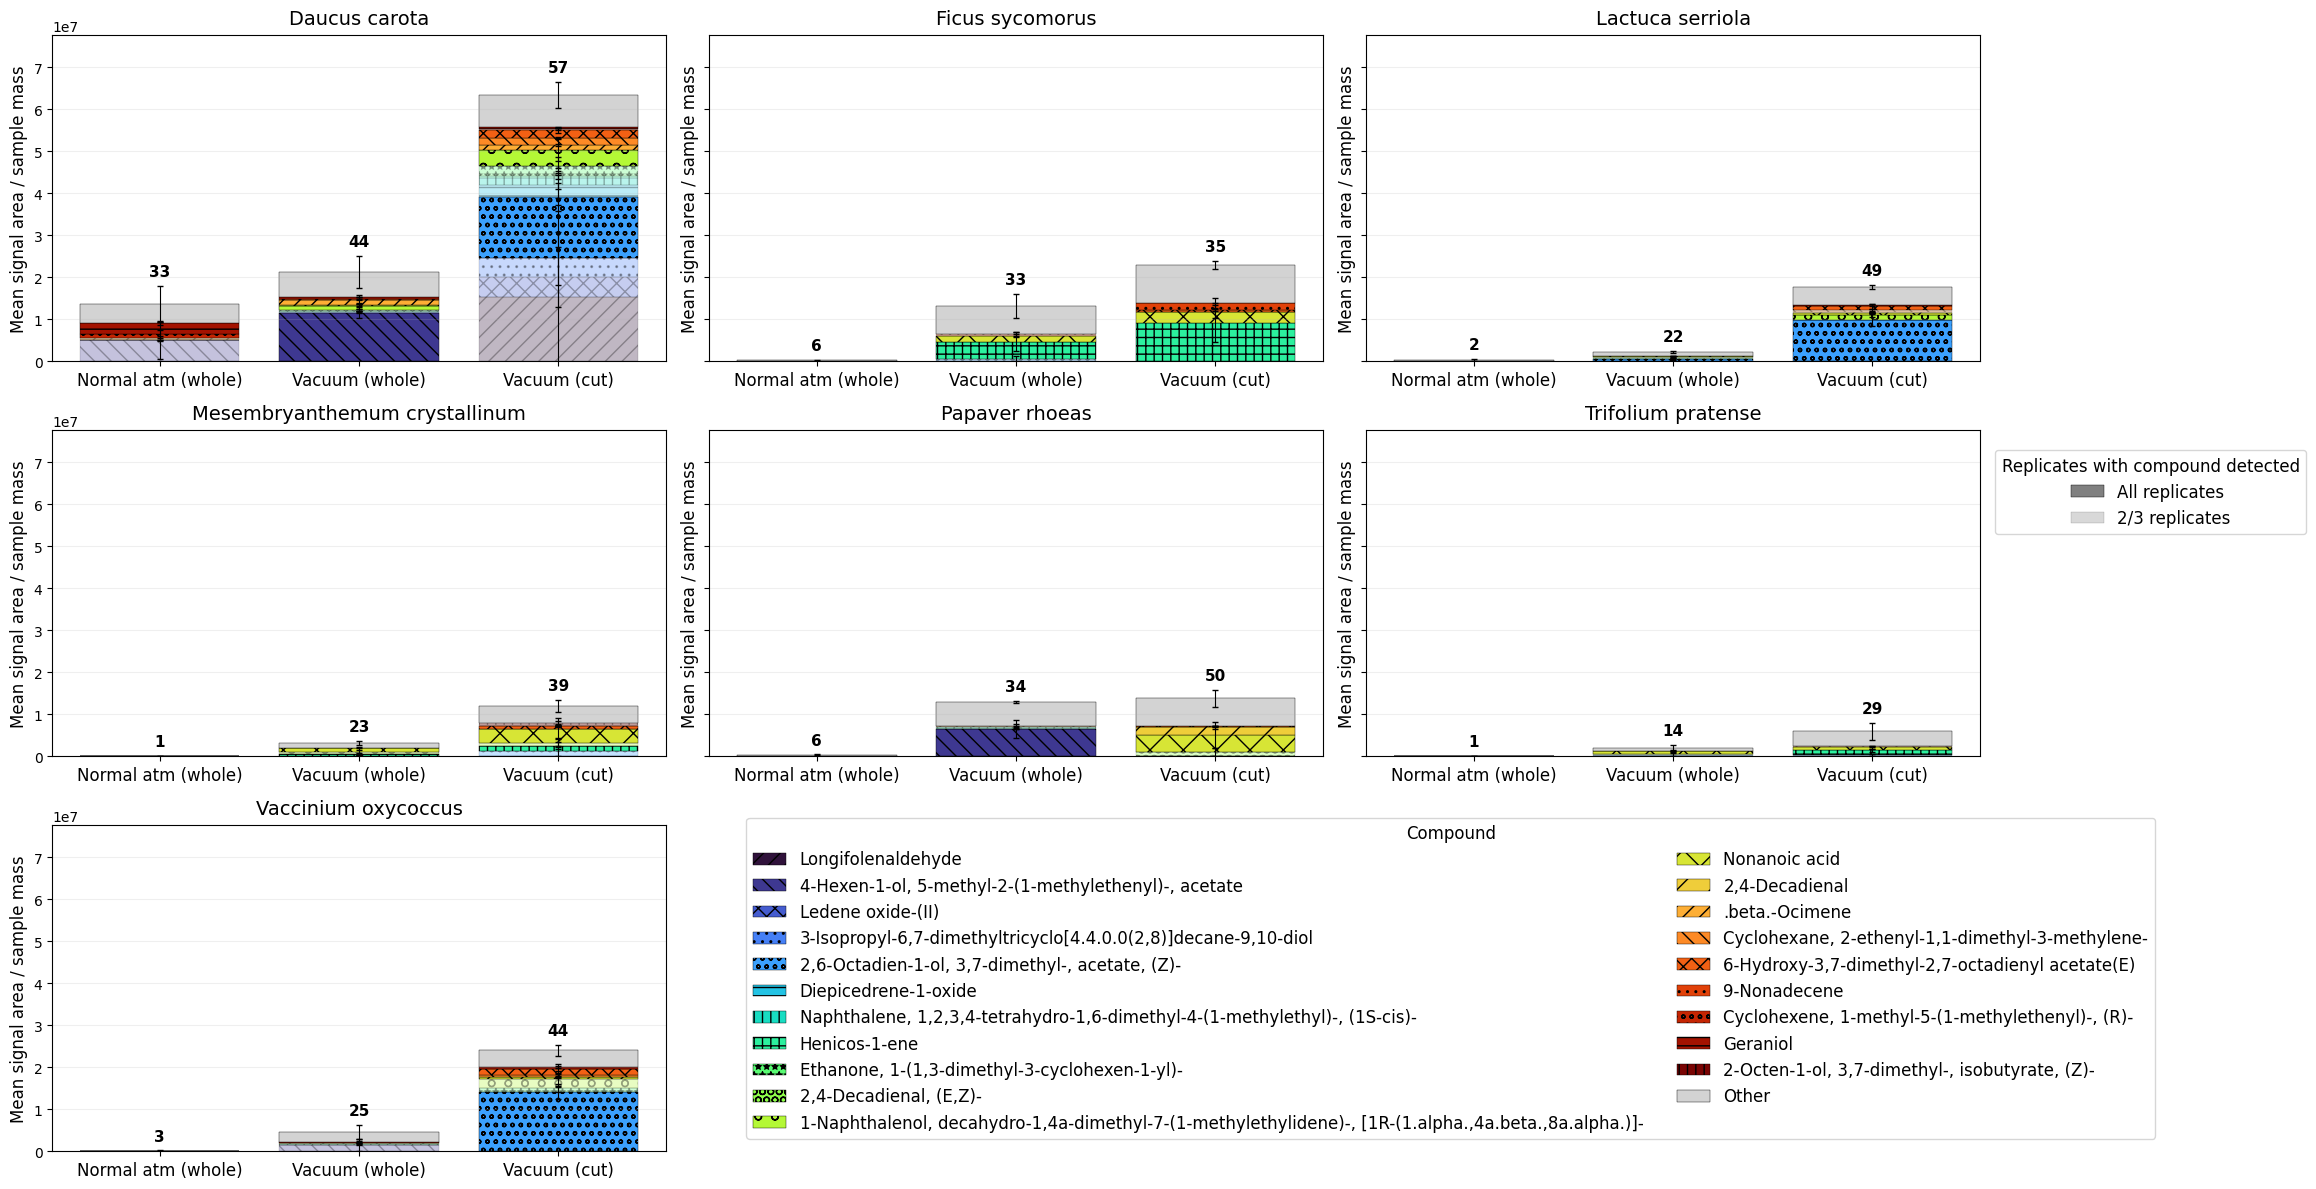

In [ ]:
# stacked bar charts for all seed-derived compounds
plot_mean_signal_area_by_species(seed_derived_df, show_compound_counts=True)

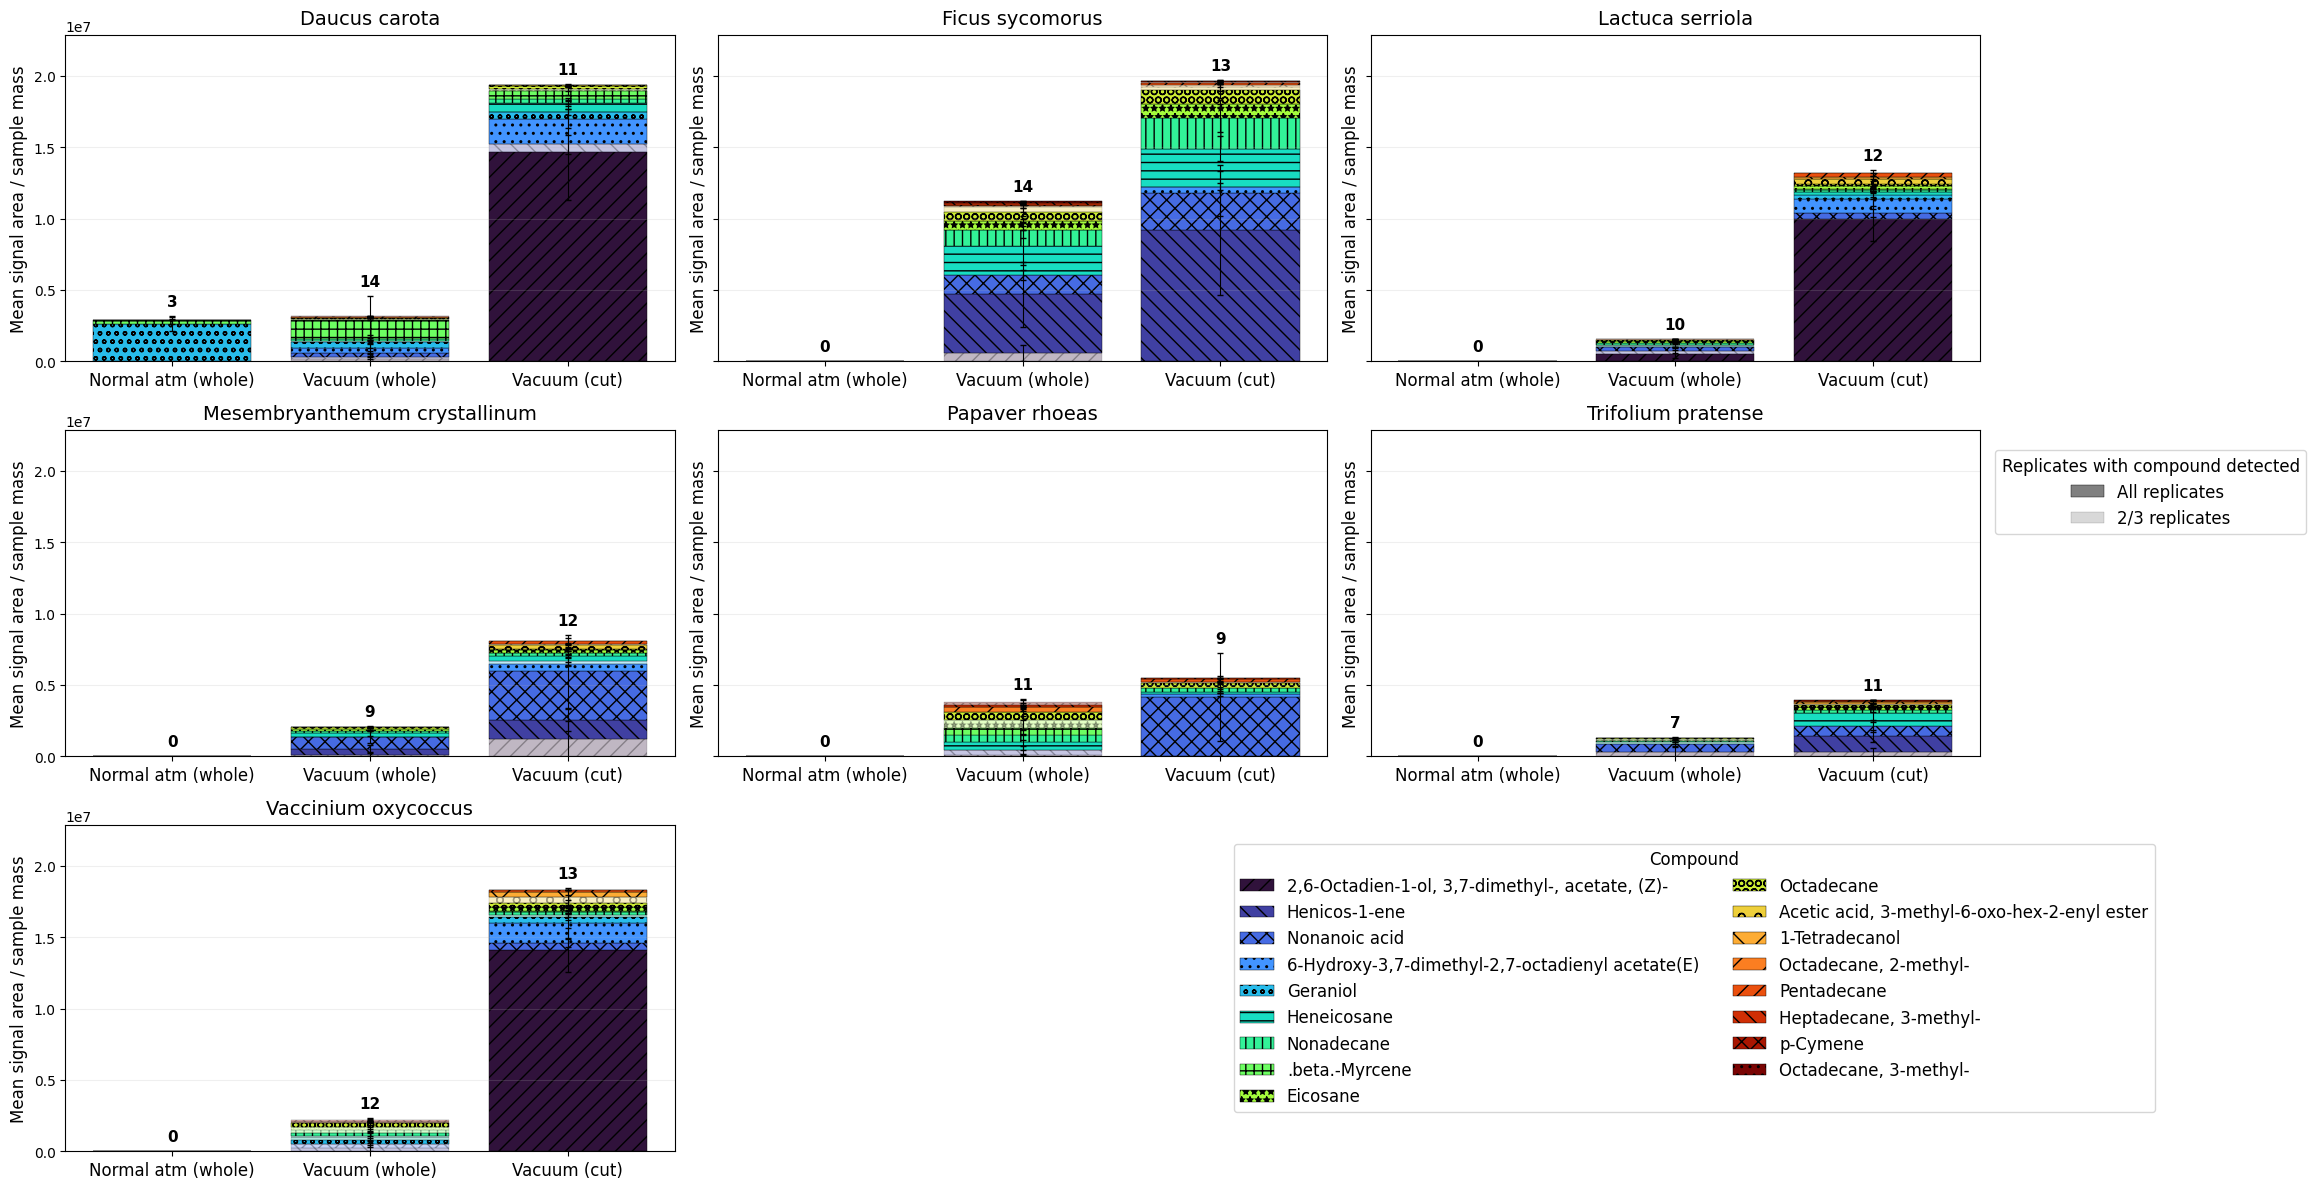

In [ ]:
# oil markers only
plot_mean_signal_area_by_species(seed_derived_df[seed_derived_df["compound_norm"].isin(oil_markers)], lump_other=False, show_compound_counts=True)

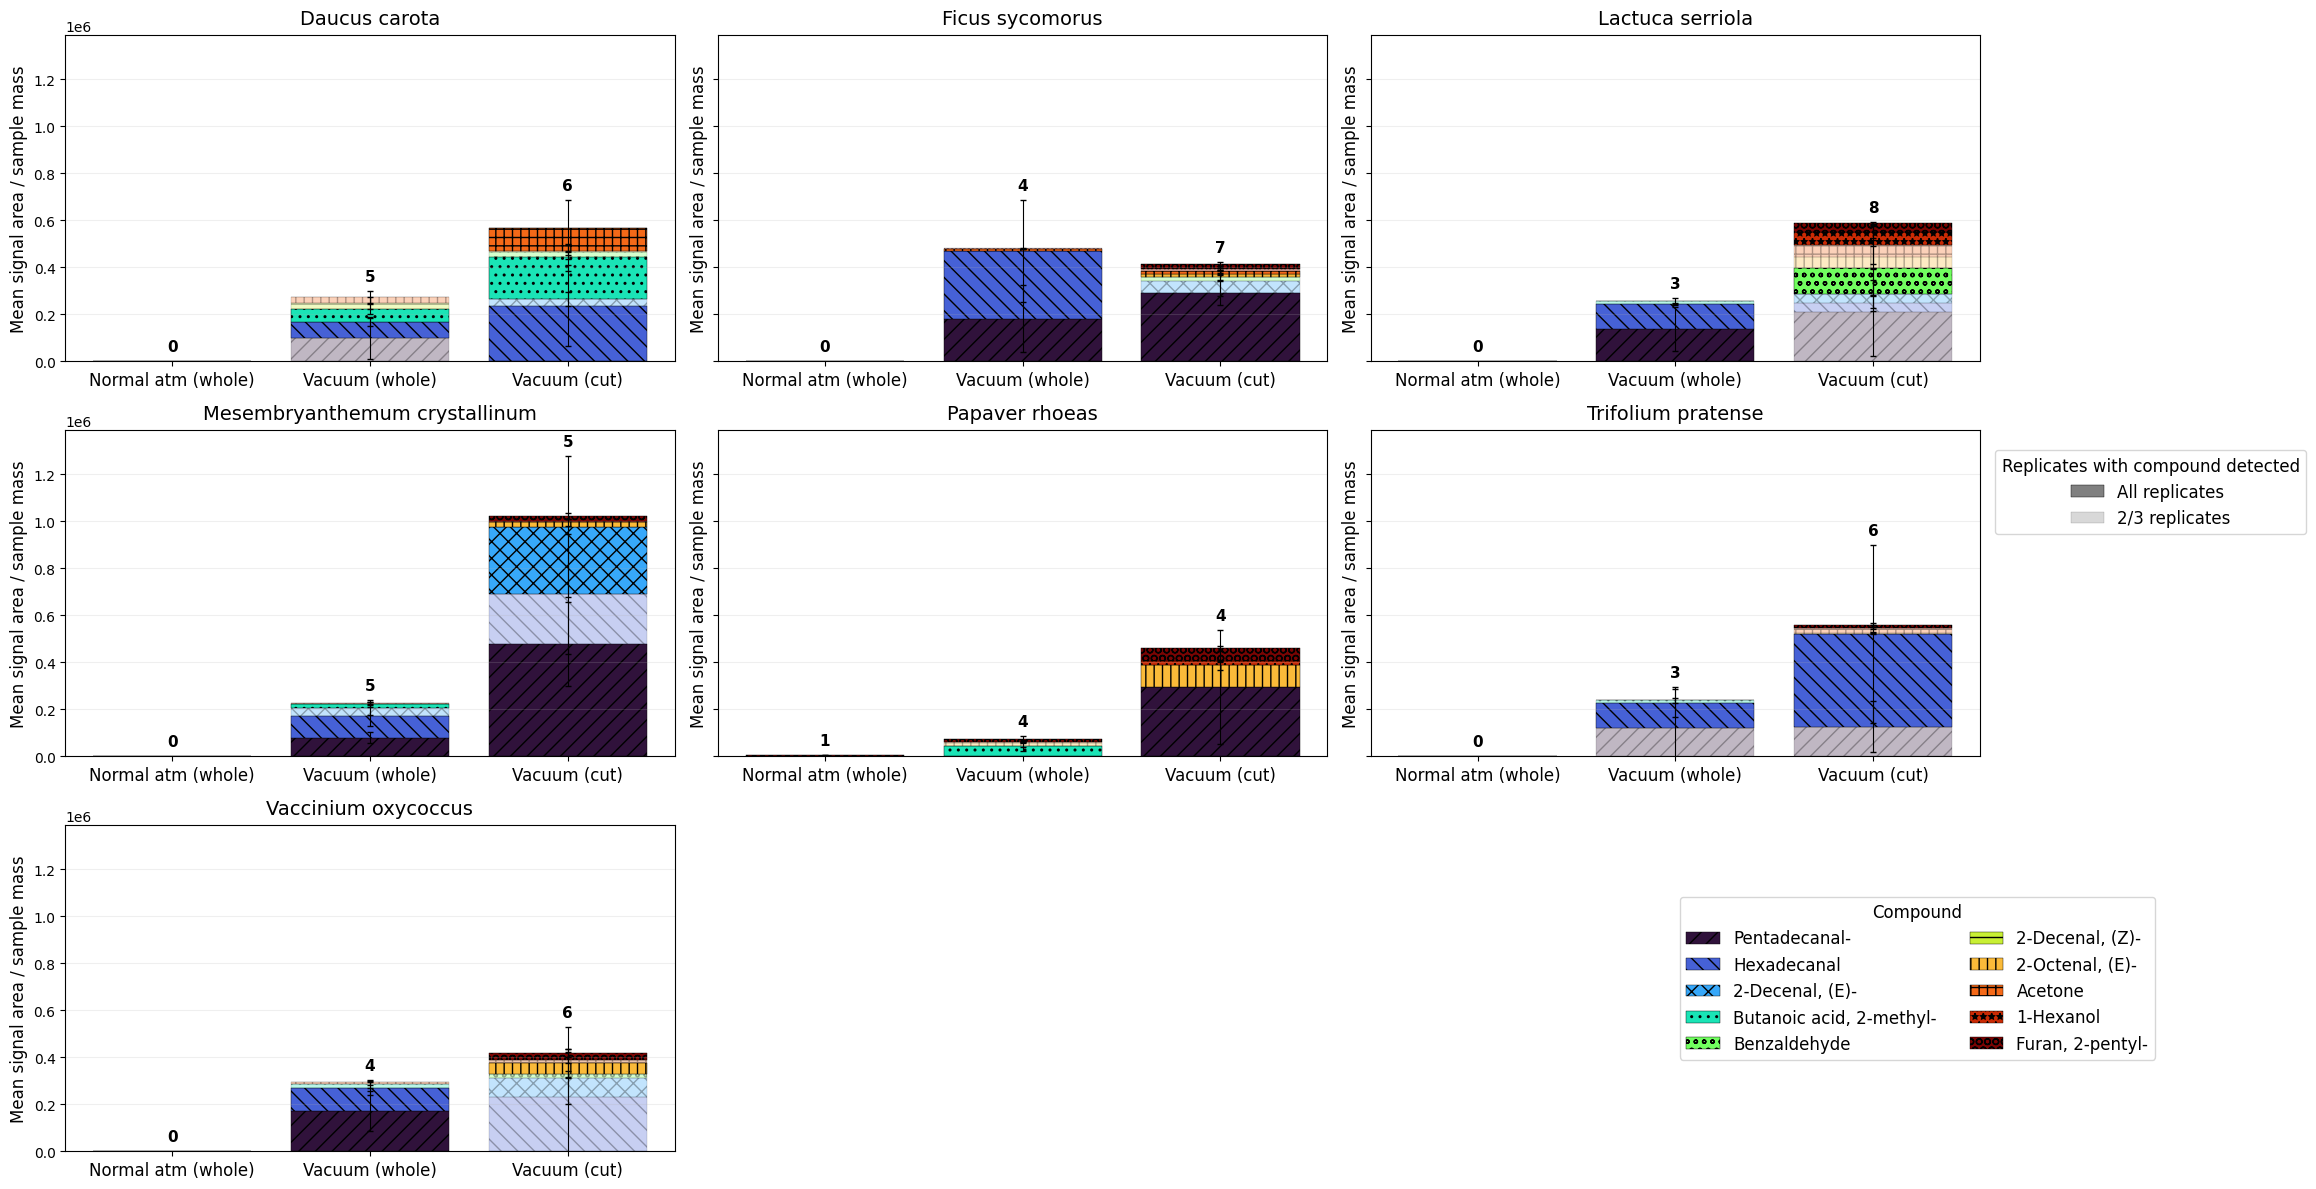

In [ ]:
# ageing markers only
plot_mean_signal_area_by_species(seed_derived_df[seed_derived_df["compound_norm"].isin(ageing_markers)], lump_other=False, show_compound_counts=True)

In [ ]:
def plot_signal_fraction_by_species(
    df,
    compounds_of_interest,
    treatments=("normal_atm_whole", "vacuum_whole", "vacuum_cut"),
    treatment_labels={
        "normal_atm_whole": "Normal atm (whole)",
        "vacuum_whole": "Vacuum (whole)",
        "vacuum_cut": "Vacuum (cut)"
    },
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    compound_col="compound_name",
    value_col="area/sample_mass",
    compound_norm_col="compound_norm",
    normalise_to="total_signal",   # "total_signal" or "selected_signal"
    stack_selected_compounds=True,
    lump_other=False,
    other_label="Other",
    top_n=None,
    figsize=(20, 8),
    show=True,
    savepath=None,
    total_errorbar=True,       # one error bar at top of full stack
    segment_errorbars=False,   # error bars on individual stacked segments
):
    """
    Plot the fraction of total GC-MS signal attributable to a selected compound group.

    Parameters
    ----------
    df : pandas.DataFrame
        Full dataframe containing all compounds.
    compounds_of_interest : list-like
        List of compounds defining the group of interest.
    normalise_to : {"total_signal", "selected_signal"}
        - "total_signal": each stacked segment is expressed as a fraction of all signal
        - "selected_signal": each stacked segment is expressed as a fraction of the
          selected-group signal only
    stack_selected_compounds : bool
        - True: stack selected compounds as fractional contributions
        - False: plot a single bar equal to total fraction from the group
    total_errorbar : bool
        If True, plot one error bar at the top of the whole stack representing
        replicate-to-replicate SD in the TOTAL selected-group fraction.
    segment_errorbars : bool
        If True, plot error bars on each stacked segment as well.
    """

    if treatment_labels is None:
        treatment_labels = {t: t for t in treatments}

    df = df.copy()
    df = df[df[treatment_col].isin(treatments)].copy()

    # ---------------------------------
    # 1) Replicate-level signal by compound
    # ---------------------------------
    rep_comp = (
        df.groupby([species_col, treatment_col, replicate_col, compound_col], dropna=False)[value_col]
          .sum()
          .rename("signal")
          .reset_index()
    )

    # replicate-level total across all compounds
    rep_total = (
        df.groupby([species_col, treatment_col, replicate_col], dropna=False)[value_col]
          .sum()
          .rename("total_signal")
          .reset_index()
    )

    # ---------------------------------
    # 2) Identify selected compounds
    # ---------------------------------
    if compound_norm_col in df.columns:
        selected_mask_df = df[compound_norm_col].isin(compounds_of_interest)
        selected_compounds = (
            df.loc[selected_mask_df, compound_col]
              .dropna()
              .unique()
              .tolist()
        )
    else:
        selected_compounds = list(compounds_of_interest)

    rep_selected = rep_comp[rep_comp[compound_col].isin(selected_compounds)].copy()

    # ---------------------------------
    # 3) Reduce to top_n if requested
    # ---------------------------------
    if stack_selected_compounds:
        if top_n is not None:
            selected_means = (
                rep_selected.groupby(compound_col)["signal"]
                .mean()
                .sort_values(ascending=False)
            )
            keep_compounds = list(selected_means.head(top_n).index)
        else:
            keep_compounds = sorted(rep_selected[compound_col].dropna().unique())

        if lump_other:
            rep_selected["compound_plot"] = np.where(
                rep_selected[compound_col].isin(keep_compounds),
                rep_selected[compound_col],
                other_label
            )
            compounds_plot = keep_compounds + (
                [other_label] if other_label not in keep_compounds else []
            )
        else:
            rep_selected = rep_selected[rep_selected[compound_col].isin(keep_compounds)].copy()
            rep_selected["compound_plot"] = rep_selected[compound_col]
            compounds_plot = keep_compounds
    else:
        rep_selected["compound_plot"] = "Selected group"
        compounds_plot = ["Selected group"]

    rep_selected = (
        rep_selected.groupby([species_col, treatment_col, replicate_col, "compound_plot"], as_index=False)["signal"]
        .sum()
    )

    # ---------------------------------
    # 4) Selected-group totals per replicate
    # ---------------------------------
    rep_selected_total = (
        rep_selected.groupby([species_col, treatment_col, replicate_col], as_index=False)["signal"]
        .sum()
        .rename(columns={"signal": "selected_total"})
    )

    rep_base = rep_total.merge(
        rep_selected_total,
        on=[species_col, treatment_col, replicate_col],
        how="left"
    )
    rep_base["selected_total"] = rep_base["selected_total"].fillna(0.0)

    if normalise_to == "total_signal":
        rep_base["denominator"] = rep_base["total_signal"]
        ylabel = "Fraction of total signal"
        title_suffix = "as a fraction of total signal"
    elif normalise_to == "selected_signal":
        rep_base["denominator"] = rep_base["selected_total"]
        ylabel = "Fraction within selected group"
        title_suffix = "within selected group"
    else:
        raise ValueError("normalise_to must be 'total_signal' or 'selected_signal'")

    # replicate-level TOTAL fraction for the selected group
    rep_base["total_fraction"] = np.where(
        rep_base["denominator"] > 0,
        rep_base["selected_total"] / rep_base["denominator"],
        np.nan
    )

    # ---------------------------------
    # 5) Full grid for selected components
    # ---------------------------------
    rep_grid = (
        df[df[species_col].notna() & (df[species_col] != "Empty")]
        [[species_col, treatment_col, replicate_col]]
        .drop_duplicates()
    )

    full = (
        rep_grid.assign(_k=1)
        .merge(pd.DataFrame({"compound_plot": compounds_plot, "_k": 1}), on="_k", how="outer")
        .drop(columns="_k")
    )

    full = full.merge(
        rep_selected,
        on=[species_col, treatment_col, replicate_col, "compound_plot"],
        how="left"
    )
    full["signal"] = full["signal"].fillna(0.0)

    full = full.merge(
        rep_base[[species_col, treatment_col, replicate_col, "denominator"]],
        on=[species_col, treatment_col, replicate_col],
        how="left"
    )

    full["fraction"] = np.where(
        full["denominator"] > 0,
        full["signal"] / full["denominator"],
        np.nan
    )

    # ---------------------------------
    # 6) Mean / SD for stacked segments
    # ---------------------------------
    mean_stack = (
        full.groupby([species_col, treatment_col, "compound_plot"])["fraction"]
        .mean()
        .unstack("compound_plot", fill_value=0)
        .reindex(columns=compounds_plot, fill_value=0)
    )

    sd_stack = (
        full.groupby([species_col, treatment_col, "compound_plot"])["fraction"]
        .std()
        .unstack("compound_plot", fill_value=np.nan)
        .reindex(columns=compounds_plot)
    )

    # ---------------------------------
    # 7) Mean / SD for TOTAL selected-group fraction
    # ---------------------------------
    total_fraction_stats = (
        rep_base.groupby([species_col, treatment_col])["total_fraction"]
        .agg(["mean", "std"])
        .rename(columns={"mean": "total_fraction_mean", "std": "total_fraction_sd"})
    )

    # ---------------------------------
    # 8) Presence counts for alpha logic
    # ---------------------------------
    n_total = (
        rep_grid.groupby([species_col, treatment_col])[replicate_col]
        .nunique()
        .rename("n_total_reps")
    )

    n_present = (
        rep_selected[rep_selected["signal"] > 0]
        .groupby([species_col, treatment_col, "compound_plot"])[replicate_col]
        .nunique()
        .rename("n_present_reps")
    )

    alpha_tbl = (
        pd.DataFrame(n_present)
        .join(n_total, how="right")
        .fillna({"n_present_reps": 0})
    )
    alpha_tbl["frac"] = alpha_tbl["n_present_reps"] / alpha_tbl["n_total_reps"]

    MIN_ALPHA = 0.15

    def get_alpha(sp, trt, comp):
        try:
            a = float(alpha_tbl.loc[(sp, trt, comp), "frac"])
            if a > 0.75:
                alpha = 1.0
            elif (a > 0.5) and (a < 0.75):
                alpha = 0.3
            elif a < 0.5:
                alpha = 0.2
            else:
                alpha = 1.0
        except KeyError:
            alpha = 0.0
        return float(np.clip(alpha, MIN_ALPHA, 1.0))

    # ---------------------------------
    # 9) Species list
    # ---------------------------------
    species_list = [
        s for s in pd.unique(df[species_col])
        if pd.notna(s) and s != "Empty"
    ]
    species_list = sorted(species_list)

    # ---------------------------------
    # 10) Colors + hatches
    # ---------------------------------
    base_comps = [c for c in compounds_plot if c != other_label]
    cmap = plt.get_cmap("turbo")
    base_colors = cmap(np.linspace(0, 1, max(len(base_comps), 1)))
    colors = {c: col for c, col in zip(base_comps, base_colors)}
    if lump_other and other_label in compounds_plot:
        colors[other_label] = "lightgray"

    hatches = ['//', '\\\\', 'xx', '..', 'oo', '--', '||', '++', '**', 'OO', 'o', 'x', '/']
    hatch_map = {c: hatches[i % len(hatches)] for i, c in enumerate(compounds_plot)}
    if lump_other and other_label in compounds_plot:
        hatch_map[other_label] = ""

    # ---------------------------------
    # 11) Plot
    # ---------------------------------
    ncols = min(3, len(species_list))
    nrows = int(np.ceil(len(species_list) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize[0], figsize[1] * nrows / 2),
        sharex=False, sharey=True
    )
    axes = np.array(axes).ravel()

    ymax_seen = 0.0

    for ax, sp in zip(axes, species_list):
        idx = pd.MultiIndex.from_product([[sp], list(treatments)], names=[species_col, treatment_col])
        m = mean_stack.reindex(idx).fillna(0)
        s = sd_stack.reindex(idx)

        total_stats_sp = total_fraction_stats.reindex(idx)

        x = np.arange(len(treatments))
        xlabels = [treatment_labels.get(t, t) for t in treatments]
        bottom = np.zeros(len(treatments))

        for comp in compounds_plot:
            vals = m[comp].to_numpy()
            errs = s[comp].to_numpy()

            for j, trt in enumerate(treatments):
                v = vals[j]
                a = get_alpha(sp, trt, comp)

                ax.bar(
                    x[j], v,
                    bottom=bottom[j],
                    color=colors.get(comp, "lightgray"),
                    alpha=a,
                    hatch=hatch_map.get(comp, ""),
                    edgecolor="black",
                    linewidth=0.3,
                )

                if segment_errorbars:
                    e = errs[j]
                    if np.isfinite(e) and e > 0:
                        ax.errorbar(
                            x[j],
                            bottom[j] + v,
                            yerr=e,
                            fmt="none",
                            ecolor="black",
                            capsize=2,
                            linewidth=0.8,
                            zorder=10
                        )

                bottom[j] += v

        # total-stack error bars
        if total_errorbar:
            total_means = total_stats_sp["total_fraction_mean"].to_numpy()
            total_sds = total_stats_sp["total_fraction_sd"].to_numpy()

            for j in range(len(treatments)):
                tm = total_means[j]
                tsd = total_sds[j]
                if np.isfinite(tm) and np.isfinite(tsd) and tsd > 0:
                    ax.errorbar(
                        x[j],
                        tm,
                        yerr=tsd,
                        fmt="none",
                        ecolor="black",
                        capsize=4,
                        linewidth=1.2,
                        zorder=20
                    )

        ymax_local = np.nanmax(
            total_stats_sp["total_fraction_mean"].to_numpy() +
            np.nan_to_num(total_stats_sp["total_fraction_sd"].to_numpy(), nan=0.0)
        )
        ymax_seen = max(ymax_seen, ymax_local)

        ax.set_title(str(sp), fontsize=14, pad=8)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=12, rotation=0)
        ax.grid(axis="y", alpha=0.2)

    for ax in axes[len(species_list):]:
        fig.delaxes(ax)

    # sensible y limit
    if normalise_to in ["total_signal", "selected_signal"]:
        upper = min(1.05, max(0.05, ymax_seen * 1.15))
        for ax in axes[:len(species_list)]:
            ax.set_ylim(0, upper)

    # ---------------------------------
    # 12) Legends
    # ---------------------------------
    compound_handles = [
        mpatches.Patch(
            facecolor=colors.get(c, "lightgray"),
            edgecolor="black",
            linewidth=0.3,
            hatch=hatch_map.get(c, ""),
            alpha=1.0,
            label=c
        )
        for c in compounds_plot
    ]
    fig.legend(
        handles=compound_handles,
        labels=compounds_plot,
        title="Compound",
        title_fontsize=12,
        loc="center right",
        bbox_to_anchor=(0.85, 0.18),
        ncols=2,
        borderaxespad=0,
        fontsize=12
    )

    alpha_levels = [
        (1.0, "All replicates"),
        (0.3, "2/3 replicates"),
    ]
    alpha_handles = [
        mpatches.Patch(
            facecolor="gray",
            edgecolor="black",
            linewidth=0.3,
            alpha=a,
            label=lbl
        )
        for a, lbl in alpha_levels
    ]
    fig.legend(
        handles=alpha_handles,
        title="Replicates with compound detected",
        title_fontsize=12,
        bbox_to_anchor=(1.0, 0.55),
        loc="lower left",
        borderaxespad=0,
        fontsize=12
    )

    fig.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)

    if show:
        plt.show()
    else:
        plt.close(fig)

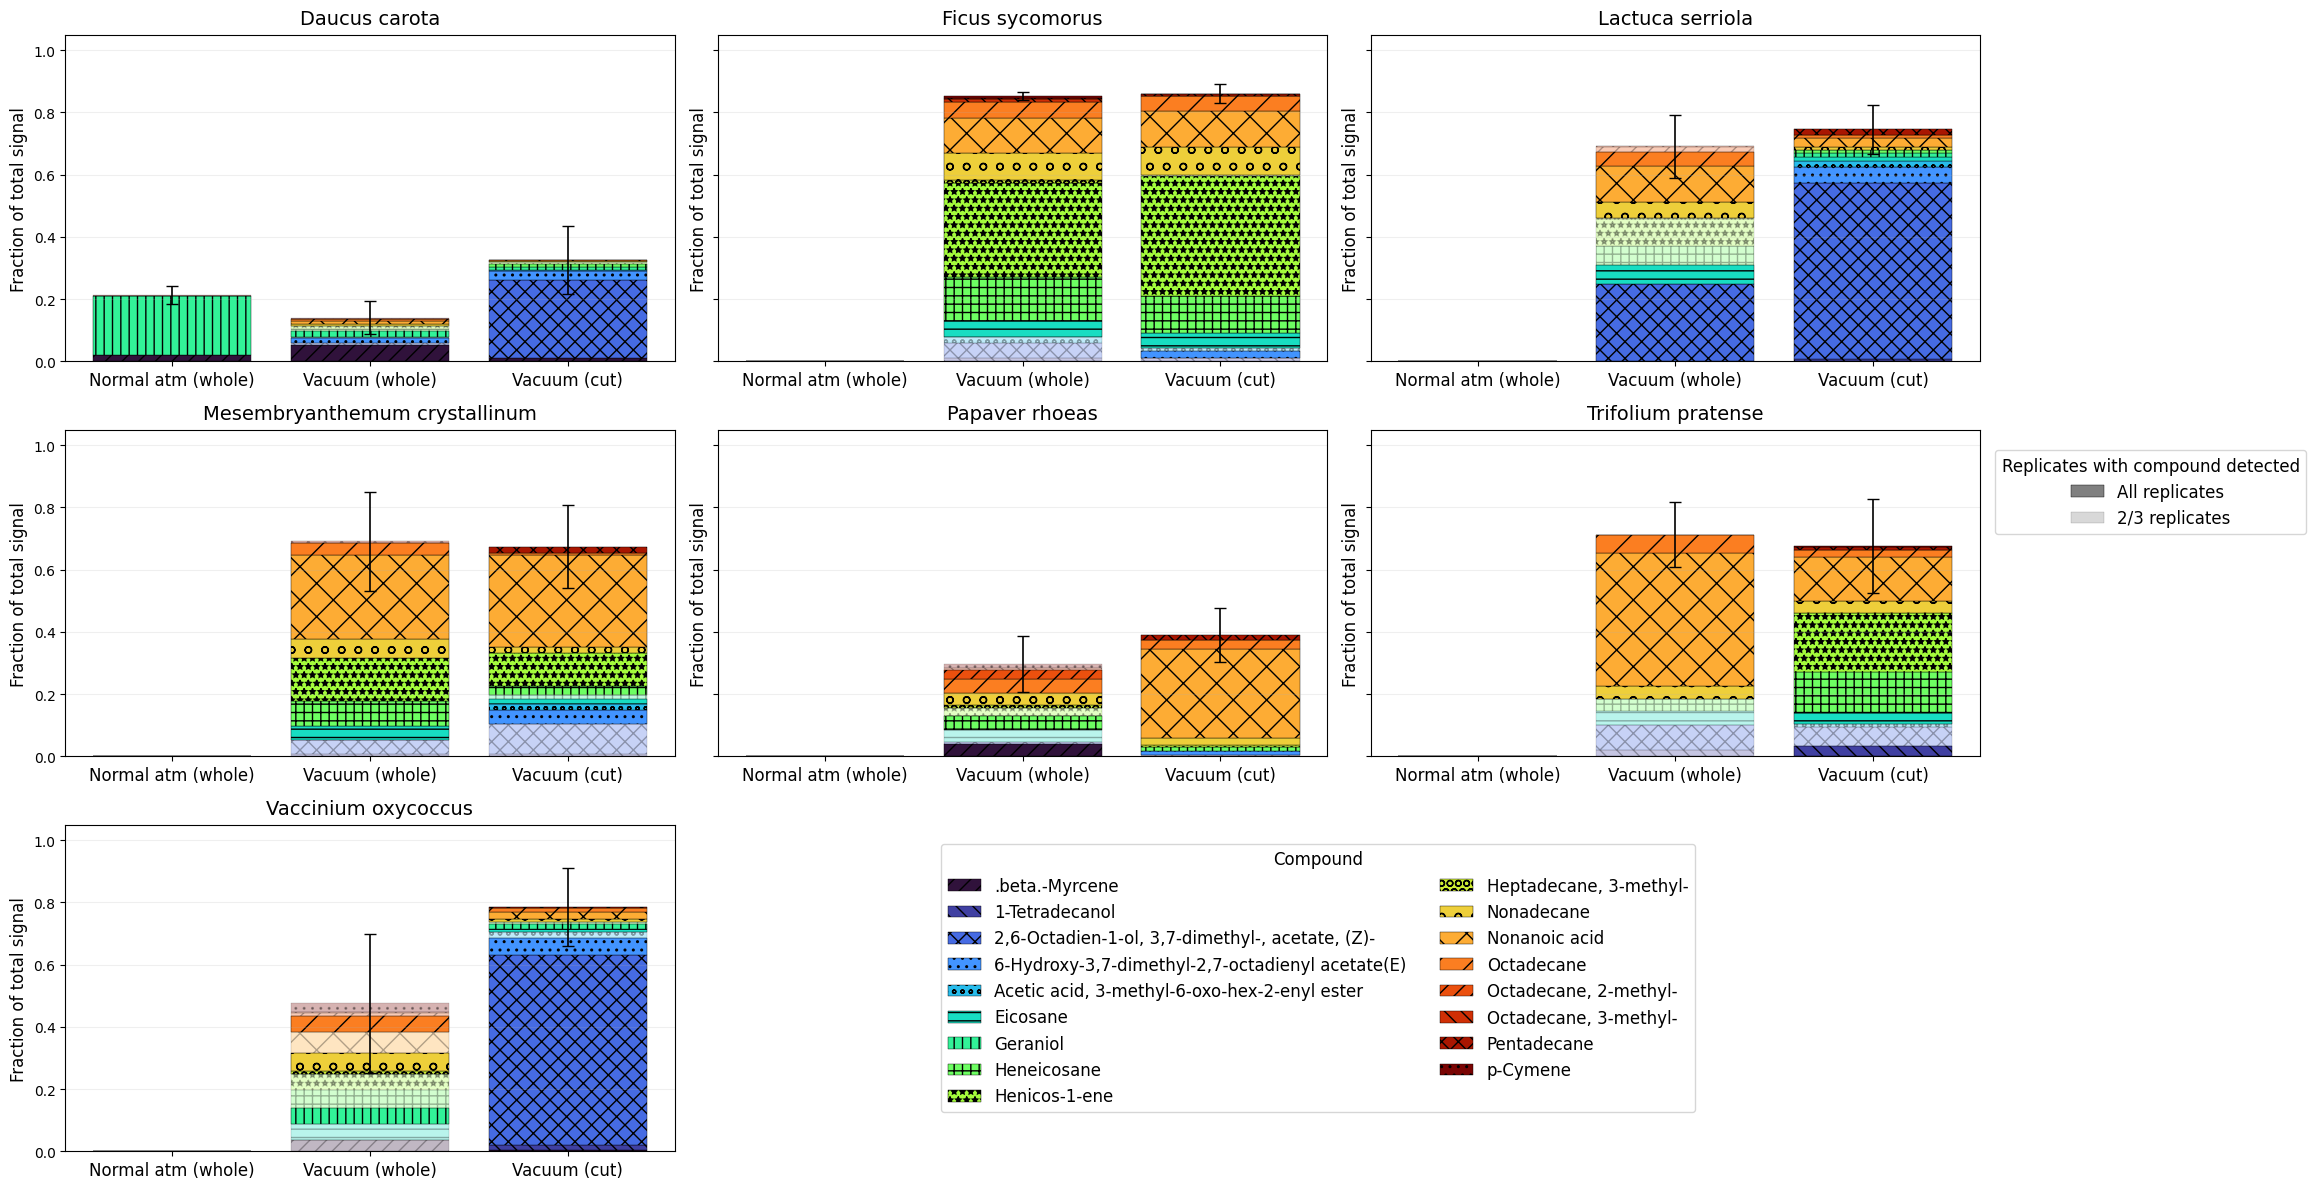

In [ ]:
# fraction of total signal from oil markers
plot_signal_fraction_by_species(
    seed_derived_df,
    compounds_of_interest=oil_markers,
    compound_norm_col="compound_norm",
    stack_selected_compounds=True,
    normalise_to="total_signal",
    lump_other=False,
    total_errorbar=True,
    segment_errorbars=False,
    savepath='Plots/fraction_signal_area_oil_markers.png',
)

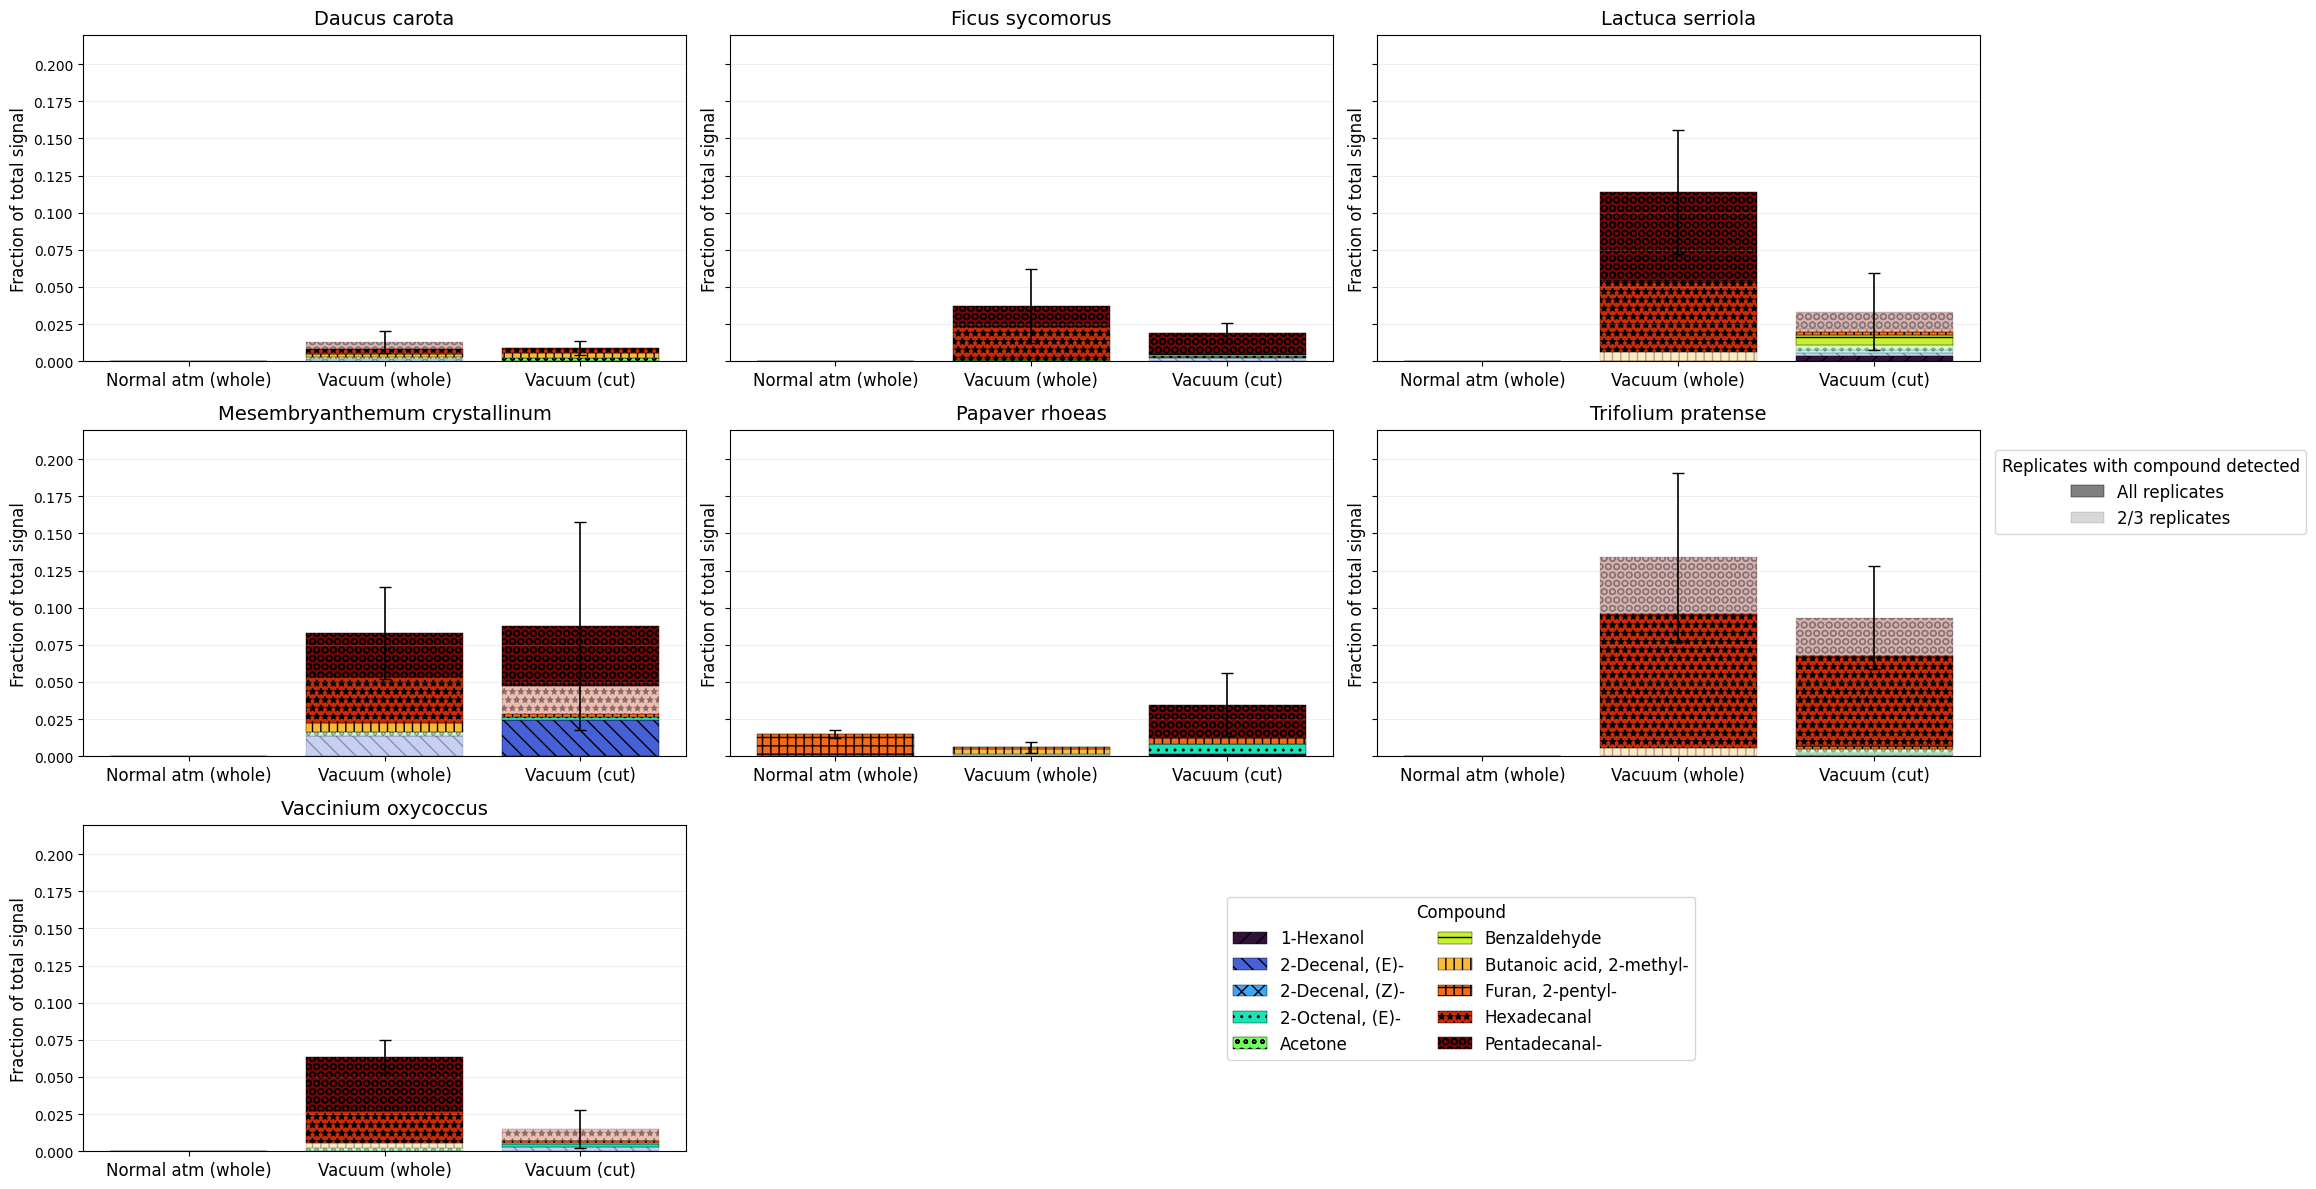

In [ ]:
# fraction of total signal from ageing markers
plot_signal_fraction_by_species(
    seed_derived_df,
    compounds_of_interest=ageing_markers,
    compound_norm_col="compound_norm",
    stack_selected_compounds=True,
    normalise_to="total_signal",
    lump_other=False,
    total_errorbar=True,
    segment_errorbars=False,
    savepath='Plots/fraction_signal_area_ageing_markers.png',
)